# TD-clip retrain — averaged curves + inference plots

Reads the runs saved by **`td_clip_retrain_sweep.ipynb`** (under
`results/retrain/<del_lim>/checkpoints_retrain_<seed>/`) and produces:

1. **Averaged retrain curves** — reward / distance / consumption per episode,
   **mean ± SE across seeds**, one band per del-lim (like the training curves).
2. **Inference vs severity** — reload every retrained model, evaluate, and plot
   signed-distance, consumption, reward, distance, calories **as del-lim severity
   increases** (smaller |clip| = more severe), averaged across seeds.
   **Positive and negative clips are separate figures.**
3. **Representative single-episode inference** — one episode each for no-clip, a
   representative +del-lim, and a representative −del-lim, showing the nutrient
   trajectories (as in the inference-normal / latent-ablation notebooks).
   Positive and negative kept in **separate** figures.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────
import os, json, glob, pickle, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from agents.ppo import PPOAgent

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print('Imports OK')

/Users/charithapalika/Desktop/Lab projects/Appetite modelling/FoodRL/FoodRL_cleaned_copies/utils/utils.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Imports OK


## Config

In [2]:
RETRAIN_ROOT = 'results/retrain_500ep'
PLOT_DIR     = 'results/plots_retrain'
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Inference eval ─────────────────────────────────────────────────────────
N_INFERENCE   = 20          # episodes PER SEED (eval is unseeded -> episodes vary)
EVAL_SEED     = 0
DETERMINISTIC = True
ROLL_WINDOW   = 25          # rolling mean window for the averaged learning curves

# ── Representative single-episode inference ───────────────────────────────
REP_SEED   = None           # which seed's model to show; None -> first available
REP_POS_DL = None           # representative +del-lim; None -> most severe (smallest +|clip|)
REP_NEG_DL = None           # representative -del-lim; None -> most severe (largest -|clip| i.e. smallest magnitude)

def dl_severity(dl):        # smaller |clip| = MORE severe; no-clip = 0 (least severe)
    return 0.0 if (dl is None or dl == 0) else abs(float(dl))

def dl_label(dl):
    if dl is None or dl == 0: return 'no clip'
    return f'{"+" if dl > 0 else "-"}{abs(float(dl)):g}'

print('Reading runs from', RETRAIN_ROOT)

Reading runs from results/retrain_500ep


## 1. Discover the saved retrain runs

In [3]:
# ── Scan results/retrain/<del_lim>/checkpoints_retrain_<seed>/ ─────────────
rows = []
for info_path in glob.glob(os.path.join(RETRAIN_ROOT, '*', 'checkpoints_retrain_*', 'retrain_info.json')):
    with open(info_path) as f:
        info = json.load(f)
    folder = os.path.dirname(info_path)
    meta   = os.path.join(folder, 'ppo_agent_ep300_meta.json')
    log    = os.path.join(folder, 'ppo_agent_ep300_log.npz')
    dl     = info.get('limit_delta')
    rows.append({'tag': info.get('del_lim_tag'), 'limit_delta': dl, 'seed': info.get('seed'),
                 'sign': (0 if (dl is None or dl == 0) else (1 if dl > 0 else -1)),
                 'severity': dl_severity(dl), 'folder': folder,
                 'meta': meta, 'log': log,
                 'has_meta': os.path.exists(meta), 'has_log': os.path.exists(log)})
runs_df = pd.DataFrame(rows).sort_values(['sign', 'severity', 'seed']).reset_index(drop=True)

assert len(runs_df) > 0, f'No runs found under {RETRAIN_ROOT} — run td_clip_retrain_sweep.ipynb first.'
print(f'Found {len(runs_df)} runs | del-lims: {sorted(runs_df["tag"].unique())} | '
      f'seeds: {sorted(runs_df["seed"].unique())}')
display(runs_df[['tag', 'limit_delta', 'seed', 'sign', 'severity', 'has_meta', 'has_log']])

# unique del-lims, ordered: no clip, then by severity
_dls = runs_df.drop_duplicates('tag')[['tag', 'limit_delta', 'sign', 'severity']]
DEL_LIMS = _dls.sort_values(['sign', 'severity'])['limit_delta'].tolist()

Found 340 runs | del-lims: ['neg_0.0001', 'neg_0.0003', 'neg_0.0005', 'neg_0.001', 'neg_0.002', 'neg_0.003', 'neg_0.005', 'neg_1e-05', 'neg_1e-06', 'neg_2e-05', 'neg_2e-06', 'neg_3e-05', 'neg_3e-06', 'neg_5e-05', 'neg_5e-06', 'noclip', 'pos_0.0001', 'pos_0.0002', 'pos_0.0003', 'pos_0.0005', 'pos_0.001', 'pos_0.002', 'pos_0.003', 'pos_0.005', 'pos_0.03', 'pos_0.05', 'pos_1e-05', 'pos_1e-06', 'pos_2e-05', 'pos_2e-06', 'pos_3e-05', 'pos_3e-06', 'pos_5e-05', 'pos_5e-06'] | seeds: [np.int64(0), np.int64(7), np.int64(27), np.int64(42), np.int64(64), np.int64(100), np.int64(107), np.int64(1997), np.int64(2003), np.int64(2026)]


,tag,limit_delta,seed,sign,severity,has_meta,has_log
0,neg_1e-06,-0.000001,0,-1,0.000001,True,True
1,neg_1e-06,-0.000001,7,-1,0.000001,True,True
2,neg_1e-06,-0.000001,27,-1,0.000001,True,True
3,neg_1e-06,-0.000001,42,-1,0.000001,True,True
4,neg_1e-06,-0.000001,64,-1,0.000001,True,True
...,...,...,...,...,...,...,...
335,pos_0.05,0.050000,100,1,0.050000,True,True
336,pos_0.05,0.050000,107,1,0.050000,True,True
337,pos_0.05,0.050000,1997,1,0.050000,True,True
338,pos_0.05,0.050000,2003,1,0.050000,True,True


## 2. Averaged retrain curves (mean ± SE across seeds)

Split into two figures: **no clip + positive del-lim** and **no clip + negative del-lim**. reward / distance / consumption per episode.

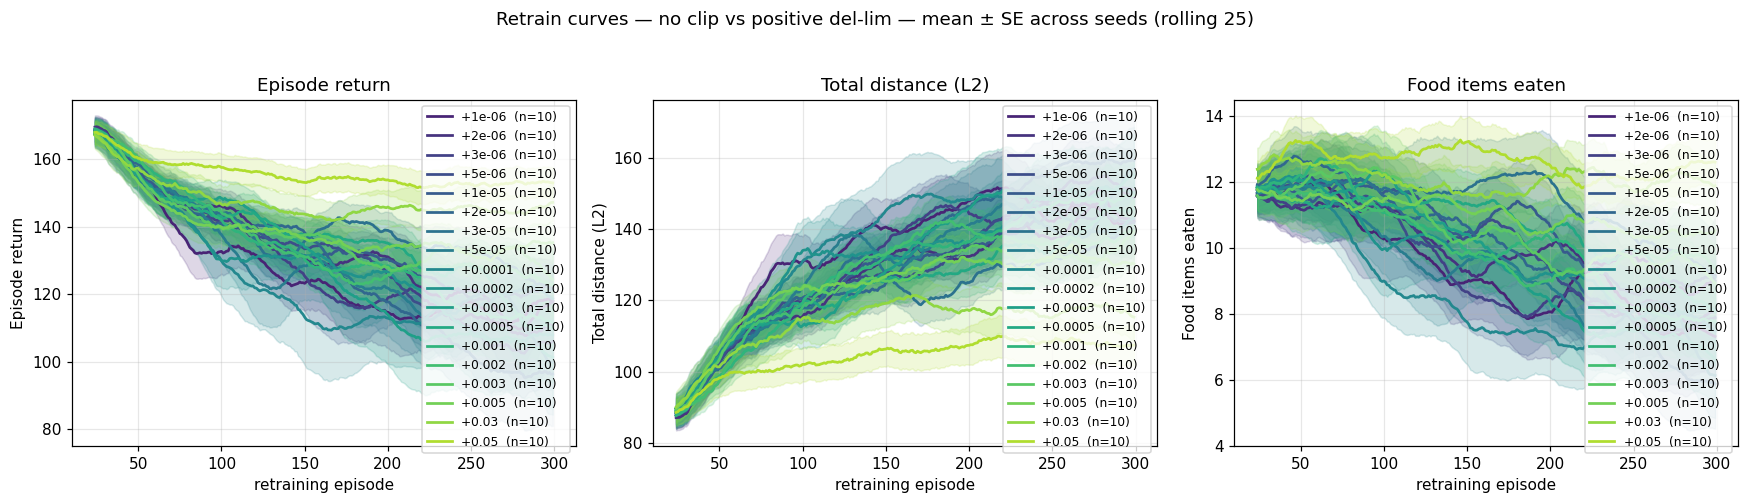

Saved results/plots_retrain/retrain_curves_avg_positive.png


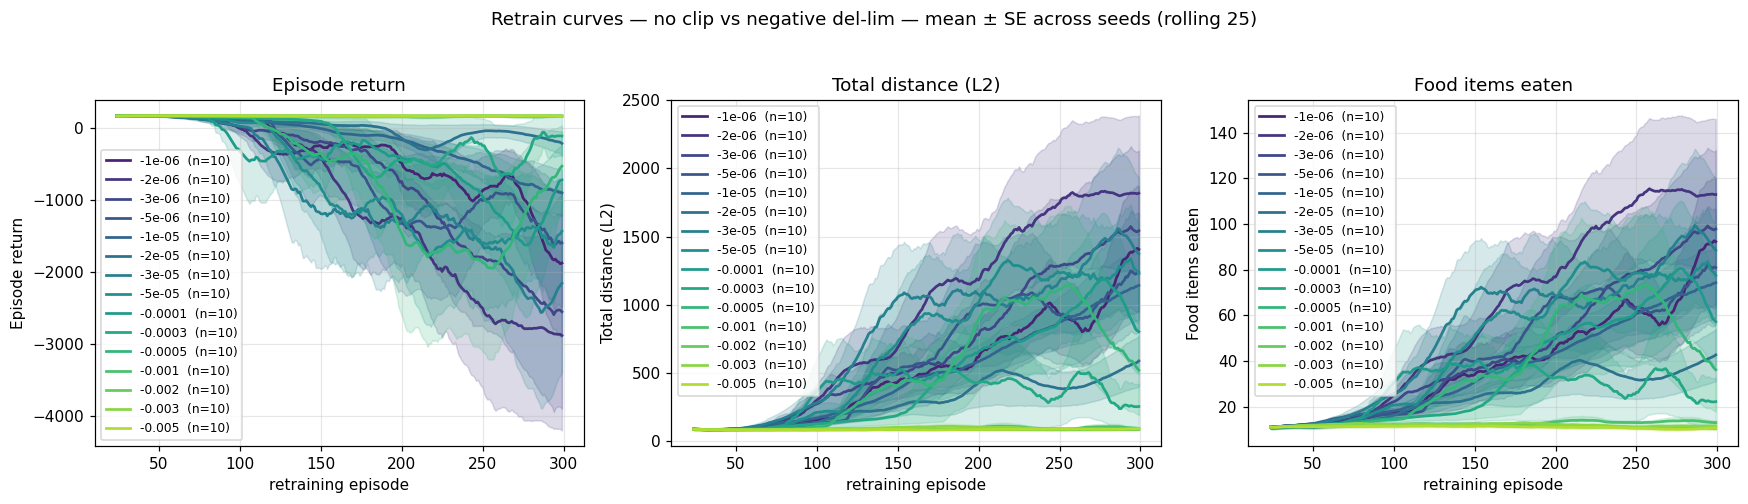

Saved results/plots_retrain/retrain_curves_avg_negative.png


In [4]:
# ── Stack each del-lim's per-episode logs across seeds -> mean ± SE ────────
def _load_log(path):
    d = np.load(path)
    return {k: d[k] for k in d.files}

def _stack_metric(logs, key):
    arrs = [np.asarray(l[key], dtype=float) for l in logs if key in l]
    T = min(len(a) for a in arrs)
    M = np.stack([a[:T] for a in arrs])          # (n_seeds, T)
    mu = M.mean(0)
    se = M.std(0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros(T)
    return mu, se

def _rmean(x, w):
    x = np.asarray(x, float)
    return x if len(x) < w else np.convolve(x, np.ones(w) / w, mode='valid')

metrics = [('reward', 'Episode return'), ('distance', 'Total distance (L2)'),
           ('consumption', 'Food items eaten')]

noclip_dls = [d for d in DEL_LIMS if (d is None or d == 0)]
pos_dls    = [d for d in DEL_LIMS if (d is not None and d > 0)]
neg_dls    = [d for d in DEL_LIMS if (d is not None and d < 0)]

def _plot_curves(sign_dls, title, fname):
    dls = noclip_dls + sign_dls
    if not sign_dls:
        print(f'skip "{title}": no matching-sign del-lim.'); return
    colors = plt.cm.viridis(np.linspace(0.1, 0.88, len(dls)))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    for dl, col in zip(dls, colors):
        sub  = runs_df[runs_df['limit_delta'].apply(lambda v: (v is None and dl is None) or v == dl)]
        logs = [_load_log(p) for p in sub['log'] if os.path.exists(p)]
        if not logs:
            continue
        n_seed = len(logs)
        for ax, (key, label) in zip(axes, metrics):
            mu, se = _stack_metric(logs, key)
            mu_r = _rmean(mu, ROLL_WINDOW); se_r = _rmean(se, ROLL_WINDOW)
            x = np.arange(len(mu))[len(mu) - len(mu_r):]
            ax.plot(x, mu_r, lw=1.8, color=col, label=f'{dl_label(dl)}  (n={n_seed})')
            ax.fill_between(x, mu_r - se_r, mu_r + se_r, color=col, alpha=0.18)
    for ax, (key, label) in zip(axes, metrics):
        ax.set_title(label); ax.set_xlabel('retraining episode'); ax.set_ylabel(label)
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle(f'{title} — mean ± SE across seeds (rolling {ROLL_WINDOW})', y=1.03, fontsize=12)
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, fname), bbox_inches='tight')
    plt.show()
    print(f'Saved {PLOT_DIR}/{fname}')

_plot_curves(pos_dls, 'Retrain curves — no clip vs positive del-lim', 'retrain_curves_avg_positive.png')
_plot_curves(neg_dls, 'Retrain curves — no clip vs negative del-lim', 'retrain_curves_avg_negative.png')


## 3. Inference — evaluate every retrained model

In [5]:
# ── Inference helpers ──────────────────────────────────────────────────────
def _sleep_windows(awake):
    wins, in_s, st = [], False, 0
    for t, a in enumerate(awake):
        if not a and not in_s: in_s, st = True, t
        elif a and in_s:       in_s = False; wins.append((st, t))
    if in_s: wins.append((st, len(awake)))
    return wins

def run_inference(agent, env, n_episodes, deterministic=True, seed=None):
    """Per-episode return / distance / food / calories / signed-dist, + episode-0 traj.
       UNSEEDED by default (seed=None) so episodes vary; pass a seed to reproduce."""
    if seed is not None:
        torch.manual_seed(seed); np.random.seed(seed)
    n_nut = env.num_nutrients
    tgt, low, high = env._norm_targets, env._norm_target_low, env._norm_target_high
    rows, traj0, awake0 = [], None, None
    for e in range(n_episodes):
        obs, _ = env.reset(seed=(None if seed is None else seed + e))
        done, R, D, S = False, 0.0, 0.0, 0.0
        phys, awake, nsteps = [], [], 0
        while not done:
            amounts, _lp, _v, *_ = agent.act(obs, deterministic=deterministic)
            act = (amounts.squeeze(0).detach().cpu().numpy() if agent.is_continuous
                   else int(amounts.squeeze(0).detach().cpu().item()))
            phy = np.asarray(obs['physiological_state'][:n_nut], dtype=float).copy()
            below = np.minimum(0.0, phy - low); above = np.maximum(0.0, phy - high)
            S += float((below + above).mean())          # signed distance (per step, mean over nutrients)
            phys.append(phy); awake.append(bool(obs['physiological_state'][-2] > 0.5))
            obs, r, term, trunc, _ = env.step(act); done = term or trunc
            R += r; D += float(np.linalg.norm(phy - tgt)); nsteps += 1
        rows.append({'episode': e, 'return': R, 'distance': D,
                     'food_items': len(env._step_consumption),
                     'calories': float(env.episode_calories_consumed()),
                     'signed_dist': S / max(nsteps, 1)})
        if e == 0:
            traj0, awake0 = np.array(phys), np.array(awake)
    return pd.DataFrame(rows), traj0, awake0

def load_agent(meta_path):
    return PPOAgent.from_checkpoint(meta_path, device='cpu')

# ── Evaluate every model (all seeds); KEEP every episode (pool seeds x eps) ─
per_ep = []
for _, r in runs_df.iterrows():
    if not r['has_meta']:
        print(f"  skip {r['tag']} seed {r['seed']}: missing meta"); continue
    agent = load_agent(r['meta']); env = agent.env
    df, _, _ = run_inference(agent, env, N_INFERENCE, DETERMINISTIC)     # unseeded, N per seed
    df = df.assign(tag=r['tag'], limit_delta=r['limit_delta'], seed=r['seed'],
                   sign=r['sign'], severity=r['severity'])
    per_ep.append(df)

per_ep_df = pd.concat(per_ep, ignore_index=True)          # one row per (del_lim, seed, episode)
per_ep_df.to_pickle(os.path.join(PLOT_DIR, 'inference_per_episode.pkl'))
n_models = int(runs_df['has_meta'].sum())
print(f'Evaluated {n_models} models x {N_INFERENCE} eps -> {len(per_ep_df)} pooled episodes.')

# preview: per (del_lim, seed)
prev = (per_ep_df.groupby(['tag', 'seed'])
        .agg(n=('return', 'size'), return_mean=('return', 'mean'),
             food_mean=('food_items', 'mean'), cal_mean=('calories', 'mean'))
        .reset_index())
display(prev.round(3))

[FoodEnv] Loading  'glucose'  from  'food_dataset/serum_glucose.csv'
           min=70.0758  max=142.5123   foods=19   time_points=500
[FoodEnv] Loading  'peptides'  from  'food_dataset/small_peptides_absorbed.csv'
           min=0.0000  max=0.0018   foods=19   time_points=500
[FoodEnv] Loading  'fatty_acids'  from  'food_dataset/fatty_acids_absorbed.csv'
           min=0.0000  max=0.0007   foods=19   time_points=500
[FoodEnv] Ready — 19 foods | 3 time-series nutrients | 0 cumulative nutrients
[FoodEnv] Loading shadow nutrient 'fullness'  from  'food_dataset/fullness.csv'
[FoodEnv] Loading shadow nutrient 'hunger'  from  'food_dataset/hunger.csv'
[FoodEnv] Loading shadow nutrient 'cck'  from  'food_dataset/cck.csv'
[FoodEnv] Loading shadow nutrient 'ghrelin'  from  'food_dataset/ghrelin.csv'
[FoodEnv] Loading shadow nutrient 'glp_1'  from  'food_dataset/glp_1.csv'
[FoodEnv] Loading shadow nutrient 'pyy'  from  'food_dataset/pyy.csv'
[FoodEnv] Shadow nutrients ready — 6 signal(s): ['ful

,tag,seed,n,return_mean,food_mean,cal_mean
0,neg_0.0001,0,20,-654.073,82.60,27416.891
1,neg_0.0001,7,20,166.640,11.10,4632.780
2,neg_0.0001,27,20,-1280.066,58.25,21370.595
3,neg_0.0001,42,20,163.690,10.30,3991.357
4,neg_0.0001,64,20,-1052.513,93.15,34504.758
...,...,...,...,...,...,...
335,pos_5e-06,100,20,107.398,5.35,1669.321
336,pos_5e-06,107,20,142.150,13.10,3568.504
337,pos_5e-06,1997,20,88.432,3.65,1138.882
338,pos_5e-06,2003,20,15.322,0.00,0.000


## 4. Inference vs del-lim severity — positive & negative separately

Each metric is averaged **across seeds** (mean ± SE) at each del-lim, ordered
*no clip → increasing severity* (smaller |clip| = more severe).

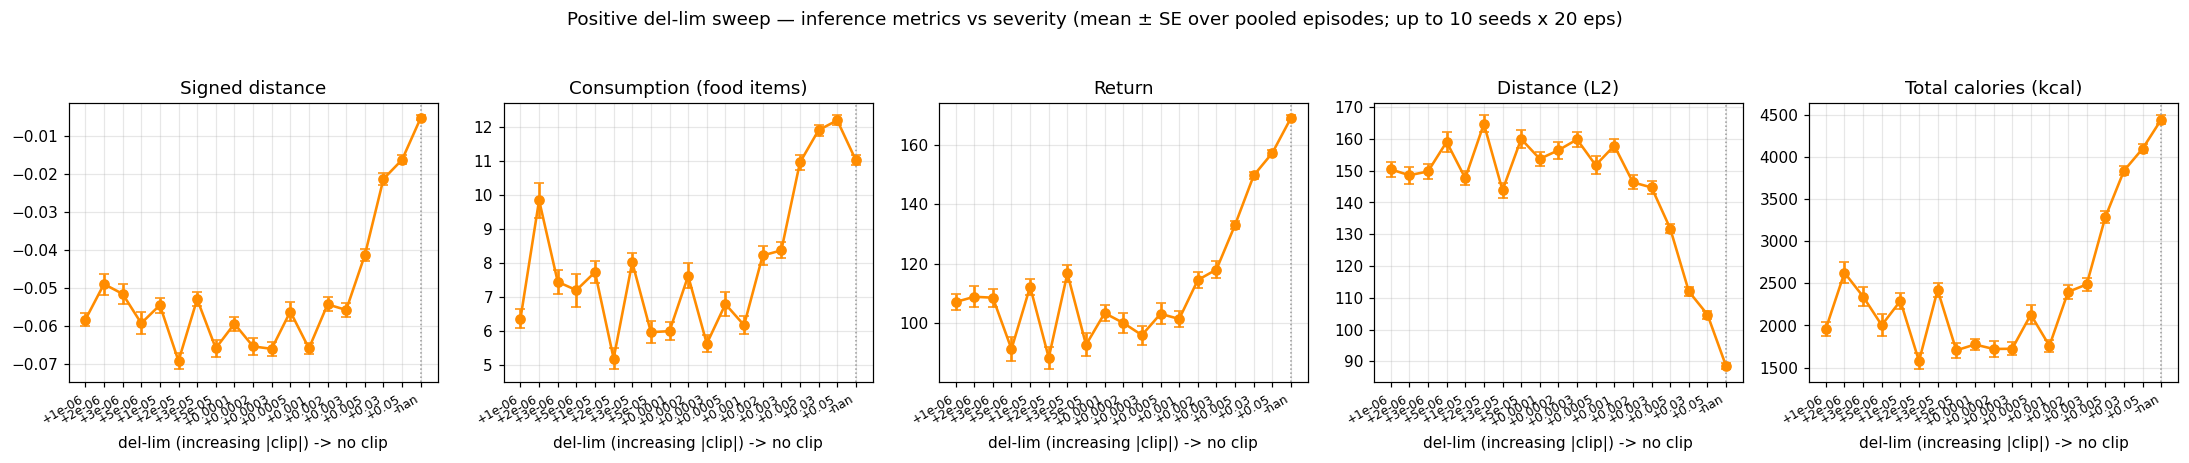

Saved results/plots_retrain/inference_vs_severity_positive.png


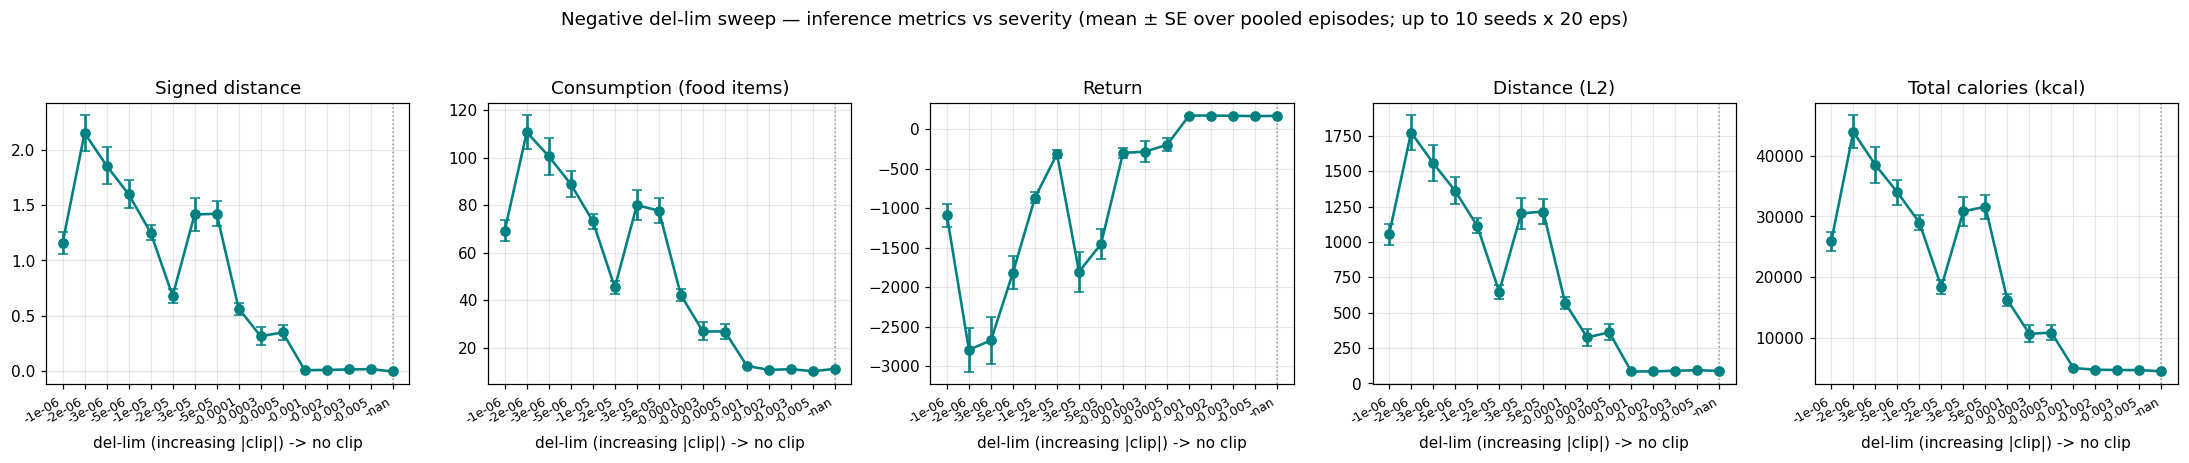

Saved results/plots_retrain/inference_vs_severity_negative.png


In [6]:
# ── Aggregate over POOLED episodes (seeds x eps), plot metrics vs severity ──
AGG_METRICS = [('signed_dist', 'Signed distance'), ('food_items', 'Consumption (food items)'),
               ('return', 'Return'), ('distance', 'Distance (L2)'), ('calories', 'Total calories (kcal)')]

def _severity_frame(df_subset, noclip_df):
    """One sign + no-clip baseline. mean ± SE computed over POOLED episodes
       (n = n_seeds x n_episodes). Order: del-lims by INCREASING |clip|, no clip LAST."""
    parts = pd.concat([noclip_df, df_subset], ignore_index=True)
    recs = []
    for (dl, sev), g in parts.groupby(['limit_delta', 'severity'], dropna=False):
        rec = {'limit_delta': dl, 'severity': sev, 'label': dl_label(dl),
               'n_episodes': len(g), 'n_seeds': int(g['seed'].nunique())}
        for key, _ in AGG_METRICS:
            rec[f'{key}_mean'] = g[key].mean()
            rec[f'{key}_sem']  = g[key].std(ddof=1) / np.sqrt(len(g)) if len(g) > 1 else 0.0
        recs.append(rec)
    fr = pd.DataFrame(recs)
    fr['is_noclip'] = fr['severity'] == 0
    return fr.sort_values(['is_noclip', 'severity'], ascending=[True, True]).reset_index(drop=True)

noclip_df = per_ep_df[per_ep_df['sign'] == 0]
pos_df    = per_ep_df[per_ep_df['sign'] > 0]
neg_df    = per_ep_df[per_ep_df['sign'] < 0]

def _plot_severity(fr, sign_name, fname, color):
    if fr.empty or fr['is_noclip'].all():
        print(f'skip {sign_name}: no {sign_name.lower()} clips found'); return
    x = np.arange(len(fr)); labels = fr['label'].tolist()
    nc_pos = int(np.where(fr['is_noclip'].values)[0][0]) if fr['is_noclip'].any() else None
    fig, axes = plt.subplots(1, len(AGG_METRICS), figsize=(4.0 * len(AGG_METRICS), 4.0))
    for ax, (key, title) in zip(axes, AGG_METRICS):
        ax.errorbar(x, fr[f'{key}_mean'], yerr=fr[f'{key}_sem'], marker='o', ms=6,
                    lw=1.7, color=color, capsize=3)
        if nc_pos is not None:
            ax.axvline(nc_pos, color='0.6', ls=':', lw=1.0)     # no-clip baseline (last)
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        ax.set_title(title); ax.grid(alpha=0.3)
        ax.set_xlabel('del-lim (increasing |clip|) -> no clip')
    n_ep = int(fr['n_episodes'].max()); n_sd = int(fr['n_seeds'].max())
    fig.suptitle(f'{sign_name} del-lim sweep — inference metrics vs severity '
                 f'(mean ± SE over pooled episodes; up to {n_sd} seeds x {N_INFERENCE} eps)',
                 y=1.04, fontsize=12)
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, fname), bbox_inches='tight')
    plt.show()
    print(f'Saved {PLOT_DIR}/{fname}')

_plot_severity(_severity_frame(pos_df, noclip_df), 'Positive', 'inference_vs_severity_positive.png', 'darkorange')
_plot_severity(_severity_frame(neg_df, noclip_df), 'Negative', 'inference_vs_severity_negative.png', 'teal')